<a href="https://colab.research.google.com/github/IrynaSukhoverkhova/my-first-work-place/blob/main/Additional_hw_5_Data_visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Додаткове завдання до модуля 4: візуалізація даних.
В цьому ДЗ ми будемо багато працювати не тільки з візуалізаціями, а і з функціоналом pandas, адже візуалізація даних - це частина аналізу даних та працює спільно з агрегацією та фільтрацією наших даних. До того ж перед тим, як аналізувати дані, їх треба почистити. Чим ми і займемось.  

0.Імпортуйте бібліотеки matplotlib.pyplot, seaborn та pandas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Набір даних Taxis

Використовуючи метод з бібліотеки `seaborn` `load_dataset` ми завантажимо перший набір даних для аналізу. Завантажимо дані так, бо це зручно + аби ви знали, що є і така можливість знайти собі набір даних для експериментів.  
Набір даних містить поїздки таксі у Нью Йорку у 2019 році. Детальний опис на [сайті](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).  

Які колонки мість набір даних:  
- `pickup` - час початку поїздки  
- `dropoff` - час закінчення поїздки  
- `passengers` - кількість пасажирів у поїздці  
- `distance` - відстань поіздки  
- `fare` - базова плата за поїздку  
- `tip` - розмір чайових  
- `tolls` - плата за платні дороги (за це також платить пасажир)  
- `total` - сумарна плата за поїздку  
- `color` - колір авто, яке здійснювало поїздку  
- `payment` - метод оплати  
- `pickup_zone` - зона, у якій почалась поїздка  
- `dropoff_zone` - зона, у якій закінчилась поїздка  
- `pickup_borough` - район, у якому почалась поїздка  
- `dropoff_borough` - район, у якому закінчилась поїздка  

Назви ознак здбільшого говорять самі за себе. Слово borough перекладається з англійської як "район".

Ми будемо працювати сами з тим шматочком даних, які наявні в seaborn.  
Переглянути всі набори даних з seaborn можна [тут](https://github.com/mwaskom/seaborn-data).

Спершу - завантажуємо дані - просто виконайте клітинку нижче.

In [2]:
df_taxi = sns.load_dataset('taxis')

1.Виведіть
- перші 3 записи з набору даних
- типи даних в наборі даних df_taxi
- розміри набору даних

In [4]:
df_taxi.head(3)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan


In [5]:
df_taxi.dtypes

,0
pickup,datetime64[ns]
dropoff,datetime64[ns]
passengers,int64
distance,float64
fare,float64
tip,float64
tolls,float64
total,float64
color,object
payment,object


Очікуваний результат (можна вивести в окремих клітинках):

![](https://drive.google.com/uc?export=view&id=1rsgJvFEdXwGDTVl3CyyRL2ao8rzR_8P2)

2.Перевіримо, чи є в цьому наборі даних пропущені значення. Для цього можемо вивести кількість пропущених значень в кожній колонці наступним чином (це надзвичайно корисна команда, запамʼятайте її):

In [6]:
df_taxi.isna().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [7]:
df_taxi.shape

(6433, 14)

Цікаво, чому дані відсутні? Відповідь на це питання нам дасть розуміння, чи можна такі дані видалити, чи можливо їх треба якось заповнити. Виведіть на екран ті рядки, де колонка, яка має найбільше пропущених значень (або одна з тих, що має максимальну кількість пропущених), має пропущені значення.
Подивіться на результат і напишіть свої думки щодо питань:
- чому на ваш погляд в цих рядках є відстуні дані в кількох колонках? Чому ви так думаєте?
- чому на ваш погляд є рядки з distance==0, а total!=0? Як ви до цього прйишли?
Відповідь просто текстом. Можна використовувати будь-які допоміжні операції над датасетом чи джерела, які допоможуть вам відповісти на ці питання. Якщо щось використовуєте, то це треба зазначити у відповіді.  

Ваша відповідь тут - це 70% виконання цього завдання.

In [8]:
max_nan_col = df_taxi.isna().sum().idxmax()
print(f"Колонка з найбільшою кількістю пропусків: {max_nan_col}")
df_taxi[df_taxi[max_nan_col].isna()]

Колонка з найбільшою кількістю пропусків: dropoff_zone


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
42,2019-03-30 23:59:14,2019-03-30 23:59:17,1,0.00,80.0,20.08,0.00,100.38,yellow,credit card,NaN,NaN,NaN,NaN
622,2019-03-12 19:52:36,2019-03-12 19:52:55,3,0.00,120.0,33.20,12.50,166.00,yellow,credit card,NaN,NaN,NaN,NaN
711,2019-03-21 17:39:50,2019-03-21 18:12:54,2,1.74,17.0,4.26,0.00,25.56,yellow,credit card,Midtown East,NaN,Manhattan,NaN
739,2019-03-14 00:09:17,2019-03-14 00:09:21,1,0.03,2.5,0.00,0.00,3.80,yellow,cash,Upper East Side South,NaN,Manhattan,NaN
970,2019-03-29 00:02:00,2019-03-29 00:02:05,2,0.00,45.0,5.00,0.00,50.30,yellow,credit card,NaN,NaN,NaN,NaN
1108,2019-03-10 09:33:13,2019-03-10 09:52:04,1,13.40,52.0,11.70,5.76,70.26,yellow,credit card,NaN,NaN,NaN,NaN
1112,2019-03-12 19:09:23,2019-03-12 19:20:46,1,0.90,8.5,1.92,0.00,14.72,yellow,credit card,Times Sq/Theatre District,NaN,Manhattan,NaN
1230,2019-03-29 07:52:46,2019-03-29 08:02:40,1,0.90,5.5,1.76,0.00,10.56,yellow,credit card,Yorkville East,NaN,Manhattan,NaN
1690,2019-03-22 06:24:14,2019-03-22 06:24:14,1,0.00,72.0,0.00,0.00,72.00,yellow,NaN,East New York,NaN,Brooklyn,NaN
1787,2019-03-28 06:58:57,2019-03-28 07:18:10,1,6.32,20.5,4.26,0.00,25.56,yellow,credit card,Manhattan Valley,NaN,Manhattan,NaN


Колонки **pickup_zone / pickup_borough** та **dropoff_zone / dropoff_borough** є взаємопов'язаними географічними атрибутами, які автоматично визначаються за GPS-координатами точки посадки/висадки. Якщо під час поїздки стався збій GPS-датчика, або точка знаходилася поза межами офіційних муніципальних кордонів Нью-Йорка, система не змогла прив'язати геопозицію ні до конкретної зони (zone), ні до району (borough). Через це пропускаються одразу обидва поля.

**Чому є рядки з distance == 0, але total != 0:**

У службі таксі Нью-Йорка за замовчуванням діє фіксована плата за посадку (так званий initial charge / flag drop fee, який нараховується в момент включення лічильника, незалежно від проїханої відстані), а також можливі тарифні збори за час очікування (idle/waiting time) чи плата за скасування поїздки (cancellation fee). Якщо пасажир сів у авто та скасував виклики після увімкнення лічильника, або авто тривалий час простояло у заторі без руху, відстань становить 0 миль (distance == 0), але підсумковий чек буде додатним (total != 0).

3.Заповнимо пусті значення. Оскільки всі колонки набору даних мають пропущені значення в рядках з типом даних рядок, заповнимо пропущені значення рядком `NA`.
Створіть набір даних `df_taxi_clean`, який містить дані `df_taxi` із заповненими пропущеними значеннями у всіх колонках (де ті значення відсутні) значенням `NA`.

**УВАГА!** Надалі в роботі треба використовувати `df_taxi_clean`, ми ж його і створили для того, аби далі ним користуватись :)

In [9]:
df_taxi_clean = df_taxi.copy()

text_cols = df_taxi_clean.select_dtypes(include=['object', 'category']).columns

df_taxi_clean[text_cols] = df_taxi_clean[text_cols].fillna('NA')

Після виконання завдання запустіть наступну клітинку:

In [11]:
df_taxi_clean.isna().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


Очікуваний результат виконання коду в попердній клітинці:

![](https://drive.google.com/uc?export=view&id=1G5_k_jmtNFFRdn7Kcw_fEoJyrkTeOGP4)

4.Хочеться подивитись на дані у динаміці. Перетворіть колонку `pickup` набору даних `df_taxi_clean` (нам нема чого працювати з "брудними" даними, якщо ми їх вже почистили, але хай будуть в окремій змінній про всяк випадок) у формат `datetime64[ns]`.
Якщо у Вас при завантаженні набору даних колонка `pickup`- вже в форматі `datetime64[ns]` - можете пропустити це завдання, або спробувати все ж таки написат функцію для трансформації.

Результат перетворення збережіть в тій самій колонці `pickup`.

In [12]:
df_taxi_clean['pickup'] = pd.to_datetime(df_taxi_clean['pickup'])

Після виконання завдання запустіть наступну клітинку:

In [13]:
df_taxi_clean.pickup.head(3)

,pickup
0,2019-03-23 20:21:09
1,2019-03-04 16:11:55
2,2019-03-27 17:53:01


Очікуваний результат виконання коду в попердній клітинці:

![](https://drive.google.com/uc?export=view&id=106hQKdEhLV3OIeFsP8yvXLo0cKk6Jmqo)

5.У нас колонка pickup зараз мість дані у форматі дата-час. Пропоную прибрати час і зробити аналітику по дням. Для цього виконайте клатинку нижче:

In [14]:
df_taxi_clean['pickup_day'] = df_taxi_clean.pickup.dt.floor('d')

А тепер згрупуйте дані по pickup_day та виведіть графік сумарних платежів по дням. УВАГА! Якщо хочете отримати підписи по осі ОХ як на прикладі, то графік необхідно будувати через `df.plot(...)`. Якщо у Вас будуть інші підписи осі ОХ - це ОК.

Після виведення графіку скажіть, чи бачите щось дивне на ньому? Важливо написати відповідь в цьому завданні словами.

In [15]:
daily_payments = df_taxi_clean.groupby('pickup_day')['total'].sum()

<Axes: xlabel='pickup_day'>

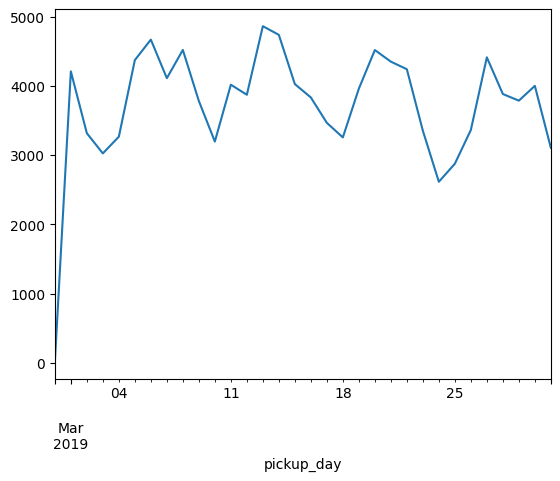

In [16]:
daily_payments.plot()

**Різкі спади на краях (неповні дані)**: на самому початку (перший день) та в кінці (останній день) спостерігається аномальне падіння суми платежів майже до нуля. Це свідчить про те, що дані за перший та останній дні є неповними (збір даних розпочався не з 00:00 першого дня або завершився до закінчення останньої доби).

**Виражена тижнева сезонність:** на графіку чітко видно регулярні циклічні коливання (піки та просідання), що повторюються кожні 7 днів. Це відображає різницю в попиті на таксі між робочими днями та вихідними.

Приклад очікуваного графіку:

![](https://drive.google.com/uc?export=view&id=1t8yb_NNO2tfwDFDrBNl0BLJoYB0BsUK_)

6.Виведіть кількість рядків для кожного pickup_day.

In [17]:
df_taxi_clean['pickup_day'].value_counts().sort_index()

,count
pickup_day,
2019-02-28,1
2019-03-01,241
2019-03-02,198
2019-03-03,169
2019-03-04,171
2019-03-05,228
2019-03-06,257
2019-03-07,218
2019-03-08,235


Маєте побачити, що для дати 2019-02-28 є тільки один рядок. Це запис, який, схоже, потрапив сюди випадково, видаліть з набору даних df_taxi_clean рядок, що містить pickup_day рівний 2019-02-28. Та знову виведіть графік сумарних платежів по pickup_day.

<Axes: xlabel='pickup_day'>

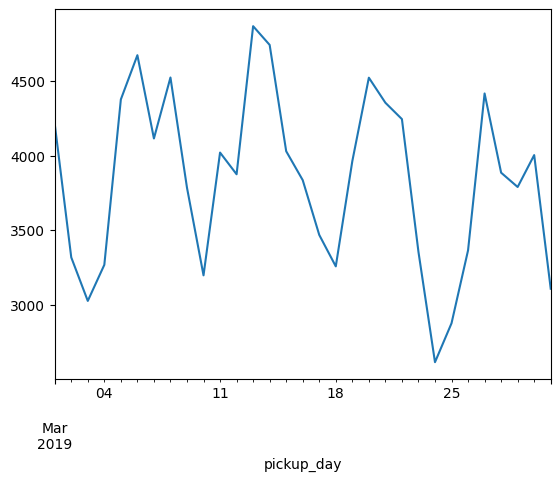

In [18]:
df_taxi_clean = df_taxi_clean[df_taxi_clean['pickup_day'] != '2019-02-28']
df_taxi_clean.groupby('pickup_day')['total'].sum().plot()

Очікуваний графік:

![](https://drive.google.com/uc?export=view&id=1RfSjsgr5991dlz5bVbfXl8tCnUZhFJ8B)

7.Давайте подивимось на динаміку сумарних платежів по районам. Для цього сформуйте на основі `df_taxi_clean` зводну таблицю, де рядками є `pickup_day`, колонками `pickup_borough`, а значенням - сума платежів. Запишіть зводну таблицю в змінну `borough_pivot`. Наостанок, вилучіть колонку зі значенням `pickup_borough` рівним `NA` - уявімо, що ці дані нас не цікавлять.

In [19]:
borough_pivot = df_taxi_clean.pivot_table(
    index='pickup_day',
    columns='pickup_borough',
    values='total',
    aggfunc='sum'
)

borough_pivot = borough_pivot.drop(columns=['NA'], errors='ignore')

Далі запустіть наступну клітинку та дайте відповідь на питання, в якому районі найчастіше найбільша сума денних платежів за поїздки на таксі?   
До речі, також рекомендую спробувати запустити команду `borough_pivot.plot()` та зрозуміти, навіщо нам тут частина `fillna(0)`.

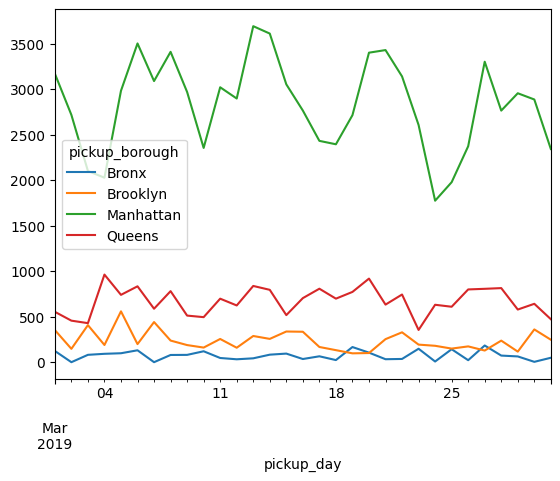

In [20]:
borough_pivot.fillna(0).plot();

Manhattan (Мангеттен) — це абсолютний лідер. Його лінія (зеленого кольору) стабільно знаходиться на найвищому рівні протягом усіх днів місяця, досягаючи $1800-$3700 на день, що в кілька разів перевищує показники інших районів (Queens, Brooklyn, Bronx).

Очікуваний графік :

![](https://drive.google.com/uc?export=view&id=1zhLnMdPCg54j2yzU1hRWv6wseSNPT1Oy)

8.Виведіть будь-яким способом гістограми суми денних платежів за поїздки по кожному з районів. Має бути 4 гістограми, на 4ох різних фігурах, або на одній.   

`Підказка:` Найпростіше це буде зробити, використавши `borough_pivot` та побудову графіку через `<назва датафрейму>.<назва графіку>()` - тобто методом датафрейму з пандаса. Але графік можна побудувати також використовуючи цикл. Для тих, хто хоче потренуватись, рекомендую зробити обома способами.

Пограйтесь з кількістю бінів. Яка кількість бінів на ваш погляд тут є вдалою? Чому?

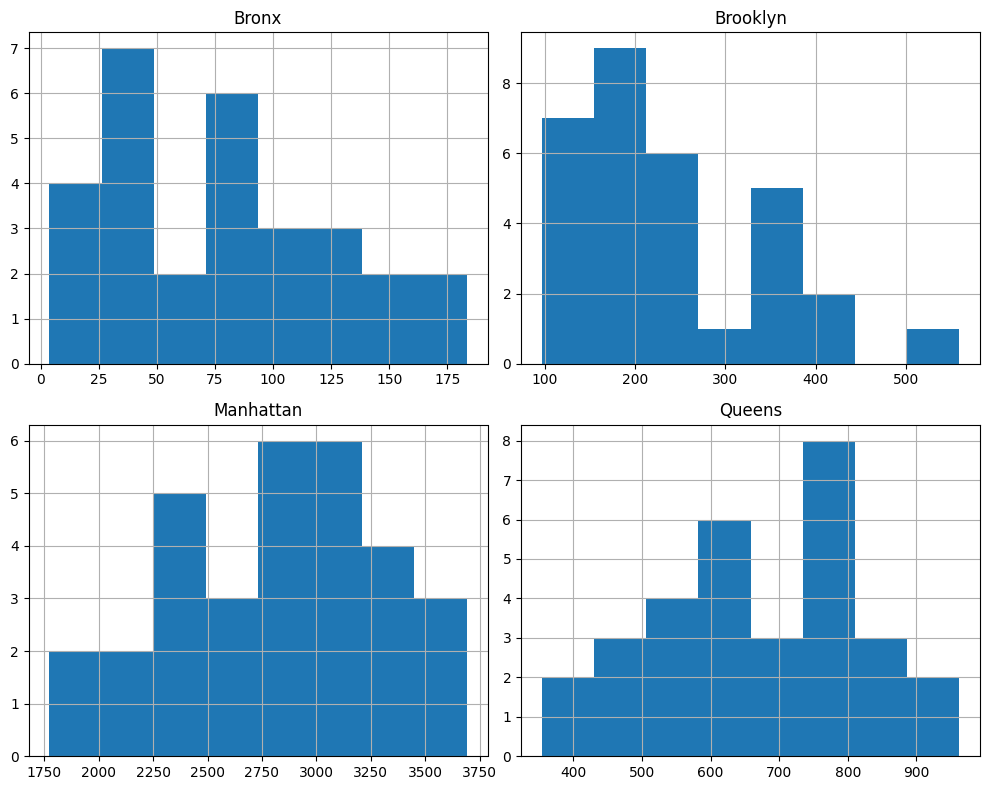

In [27]:
borough_pivot.hist(bins=8, figsize=(10, 8), grid=True)
plt.tight_layout()
plt.show()

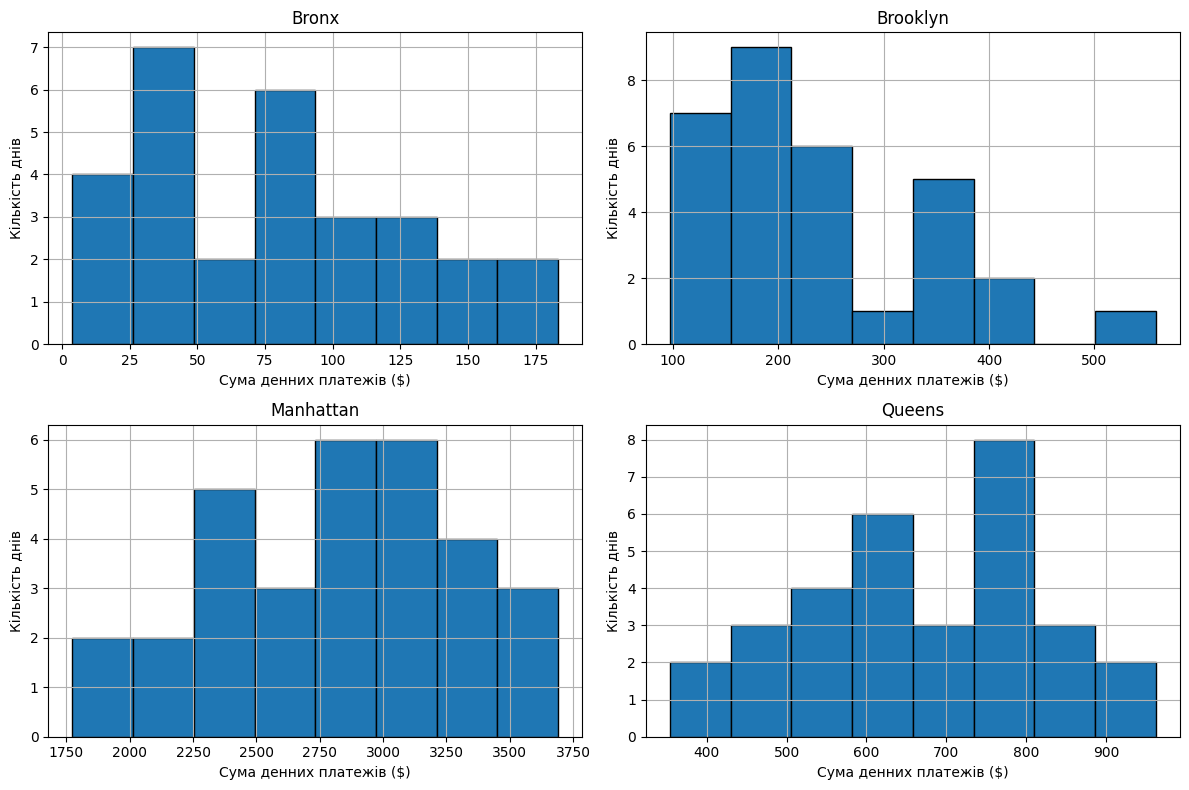

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i, column in enumerate(borough_pivot.columns, 1):
    plt.subplot(2, 2, i)
    plt.hist(borough_pivot[column].dropna(), bins=8, edgecolor='black')
    plt.title(column)
    plt.xlabel('Сума денних платежів ($)')
    plt.ylabel('Кількість днів')
    plt.grid(True)

plt.tight_layout()
plt.show()

Приклад одного з правильних виконань завдання:

![](https://drive.google.com/uc?export=view&id=1AfkIgwUAtaDiYoiK6NBOqCHBdUngRz4z)

9.Бачимо, що на окремих гістограмах у нас різні діапазони чеків. Припустимо, нам хочеться порівняти розподіли денних сум платежів по райнам. Давайте для цього виведемо 4 гістограми на одній фігурі. Вони звісно ж мають бути різного кольору і напівпрозорими для комфортного перегляду. Створіть гістограму максимально близьку до тої, що надана в очікуваному результаті.
`Підказка:` ця візуалізація створена з допомогою pandas plotting.

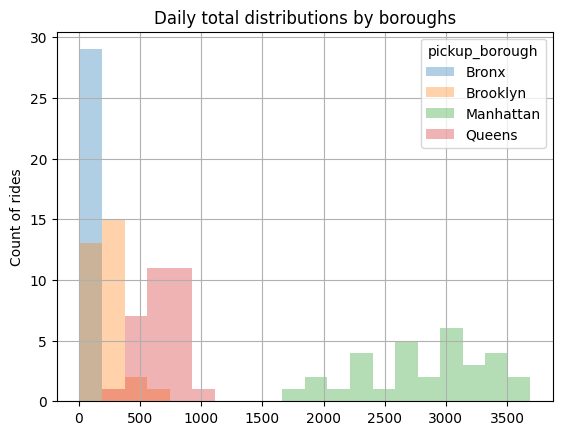

In [34]:
import matplotlib.pyplot as plt

ax = borough_pivot.plot.hist(
    alpha=0.35,
    bins=20,
    title='Daily total distributions by boroughs',
    grid=True
)

ax.set_ylabel('Count of rides')

plt.show()

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1J5PCLfVovNqeGxeeBGFUSS1Kqh6-UnwR)

А ось приклад, як можна було сформувати щось подібне з допомогою функціоналу seaborn. Як на мене візуалізація за замовчанням не є зручною для розуміння.  

`Опціональне завдання`: Пограйтесь з налаштуваннями і пошукайте варіант, за якого візуалізація розподілу суми денних платежів через seaborn є на ваш погляд зручною для аналізу.

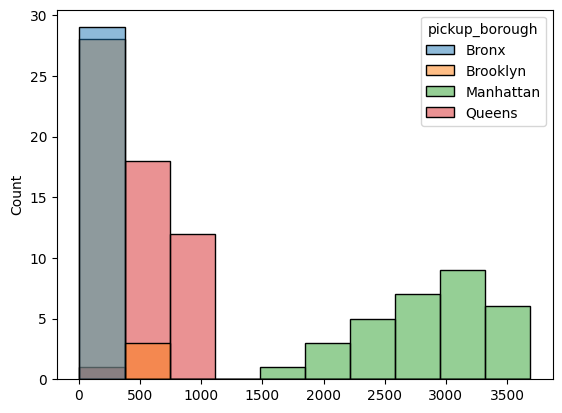

In [39]:
sns.histplot(data=borough_pivot, bins=10);

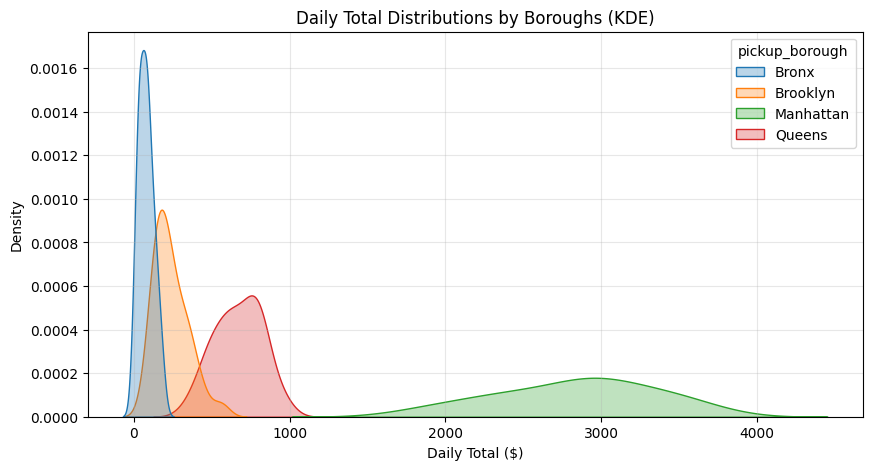

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.kdeplot(data=borough_pivot, fill=True, alpha=0.3)
plt.title('Daily Total Distributions by Boroughs (KDE)')
plt.xlabel('Daily Total ($)')
plt.grid(True, alpha=0.3)
plt.show()

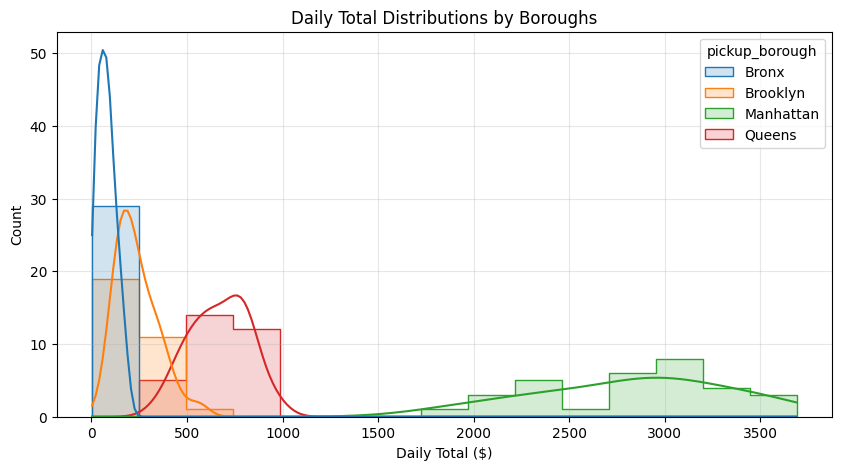

In [41]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=borough_pivot,
    element="step",
    fill=True,
    alpha=0.2,
    kde=True,
    bins=15
)
plt.title('Daily Total Distributions by Boroughs')
plt.xlabel('Daily Total ($)')
plt.grid(True, alpha=0.3)
plt.show()

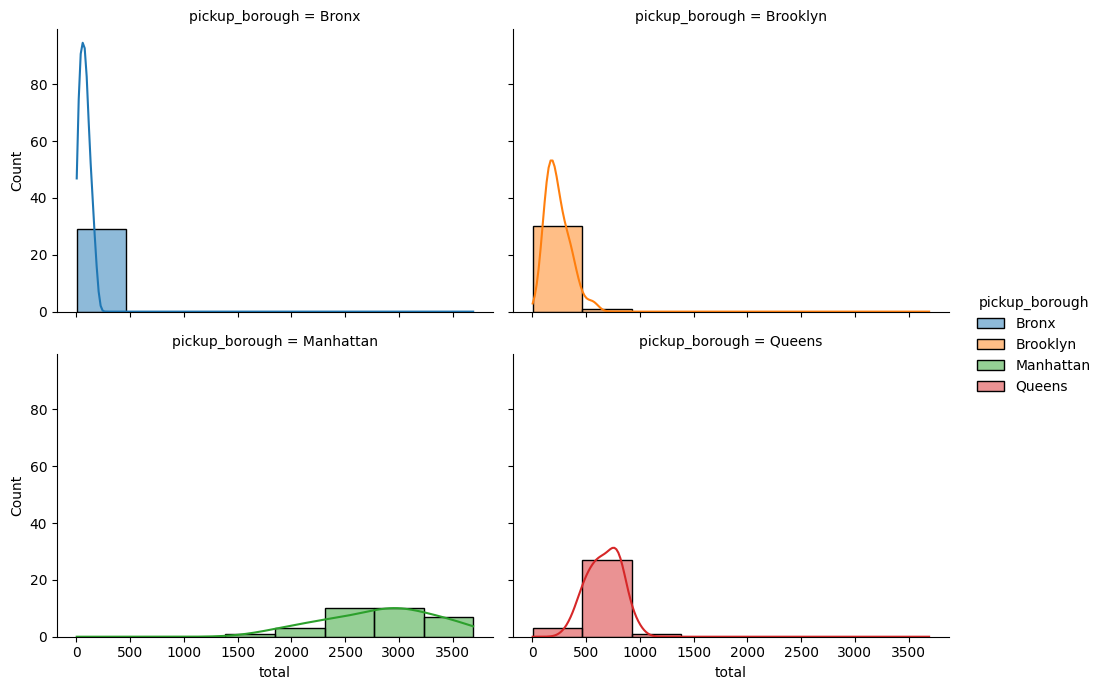

In [42]:
df_melted = borough_pivot.melt(var_name='pickup_borough', value_name='total')

sns.displot(
    data=df_melted,
    x='total',
    hue='pickup_borough',
    col='pickup_borough',
    col_wrap=2,
    kde=True,
    height=3.5,
    aspect=1.4
)
plt.show()

10.З допомогою seaborn виведіть гістограми суми щомісячних платежів по кольорам автомобілів (колонка `color`). На одній фігурі має бути кількість гістограм рівна кількості різних кольорів автомобілів в наборі даних. Встановіть розмір фігури (10,5) та знайдіть значення dots-per-inch для фігури за якого якість зображення буде хорошою (зображення не буде розмитим).
`Підказки:`
1. побудувати візуалізацію можна в один рядок коду, і ще один рядок - для встановлення розмірів і роздільної здатності фігури.
2. для зміни порядку відображення гістограм кольорів автомобілів (аби менша гістограма була перед, а не за більшою) можна посортувати датафрейм за полем кольору так, аби отримати той порядок, який вам потрібен.

<Axes: xlabel='total', ylabel='Count'>

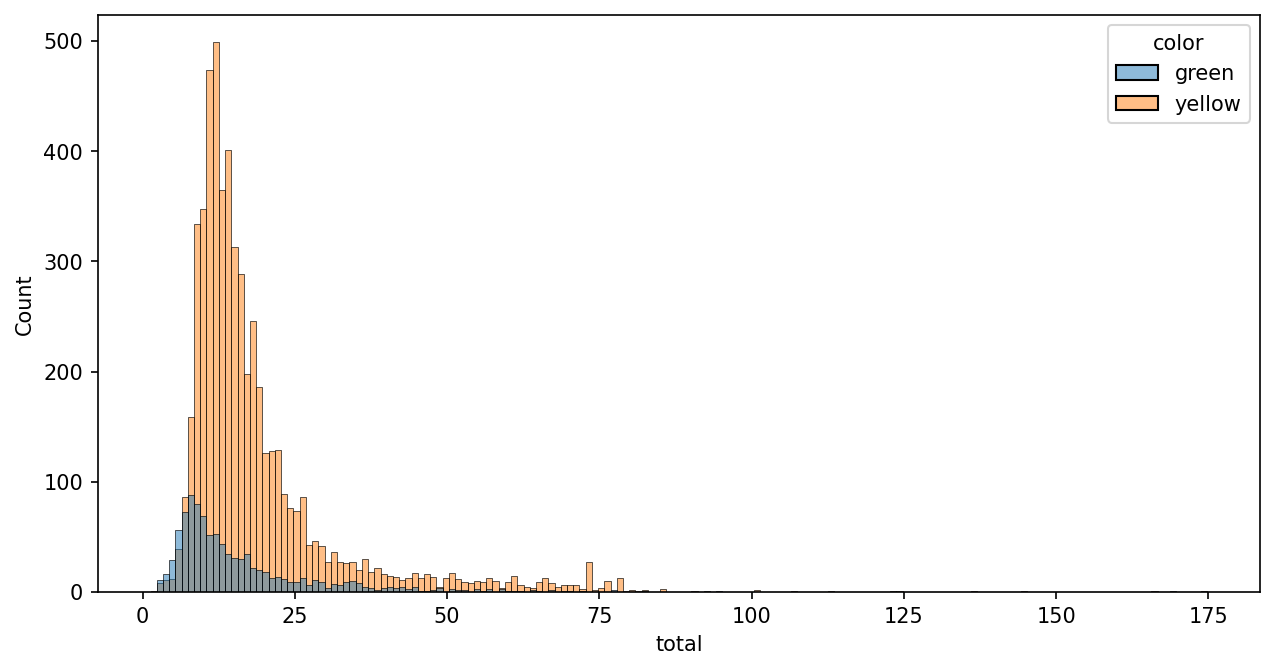

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5), dpi=150)

sns.histplot(
    data=df_taxi_clean.sort_values('color', ascending=True),
    x='total',
    hue='color',
    hue_order=['green', 'yellow'],
    palette={'green': '#1f77b4', 'yellow': '#ff7f0e'}
)

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=17j9hUAo0-65yEuCMHOHUlEW0nRqePOrW)

11.Цікаво, а чи є залежність між дальністю поїздки і розміром чайових? Побудуйте діаграму розсіювання між дальністю поїздки і розміром чайових. Можна побудувати графік будь-яким методом, який вам до вподоби, чи хочеться потренувати.

В очікуваному результаті я надаю графік, який би будувала я. На наведеному прикладі найскладніша частина - це зробити червоною цю лінію тренду (вона побудована з допомогою спеціального типу графіку в seaborn). Аби вказати колір лінії в тому типу графіку треба зазначити в параметрі `line_kws`, що ми хочемо лінію червоного кольору. Але якщо у вас не буде виходити лінія червоного кольору - нехай буде синього - це не критично :)

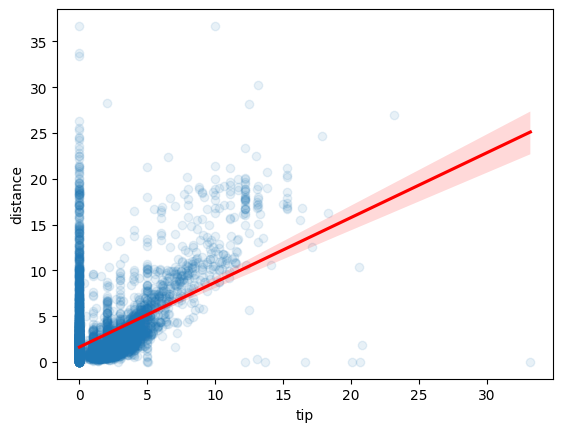

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.regplot(
    data=df_taxi_clean,
    x='tip',
    y='distance',
    line_kws={'color': 'red'},
    scatter_kws={'alpha': 0.1}
)

plt.show()

Один з можливих результатів (побудовано з seaborn):

![](https://drive.google.com/uc?export=view&id=19PtgLlPTJ1iR_AxcnBDZUw-U3Ulr6Cpy)

12.Дайте відповідь на питання: що означає пряма лінія з точок, паралельна осі, за якою розташована дальність поїздки?

Пряма вертикальна лінія з точок вздовж осі distance (при значеннях $x = 0$) означає поїздки, у яких пасажири взагалі не залишили чайових (tip = 0), незалежно від дальності поїздки.Це типове явище при оплаті готівкою (коли чайові не фіксуються в електронній системі таксометра) або коли пасажири свідомо обирають $0\%$ чайових на терміналі.

13.Побудуйте поденну динаміку чайових по районам, в яких забрали пасажира. Можна побудувати графік будь-яким методом, який вам до вподоби, чи хочеться потренувати. Важливо, щоб на одному графіку було 4 лінії (всі райони, крім `NA`), які відображають динаміку чайових, була легенда і були підписи вісей. В очікуваному результаті я надаю графік, який би будувала я.

Дайте відповіді на питання:
- при початку поїздки в якому районі **найнижчий середній розмір** чайових?
- а в поїздках з якого району **найвищий середній розмір** чайових?
- при проїздках з його району розмір чайових найстабільніший (найменше змінюється з дня у день)?

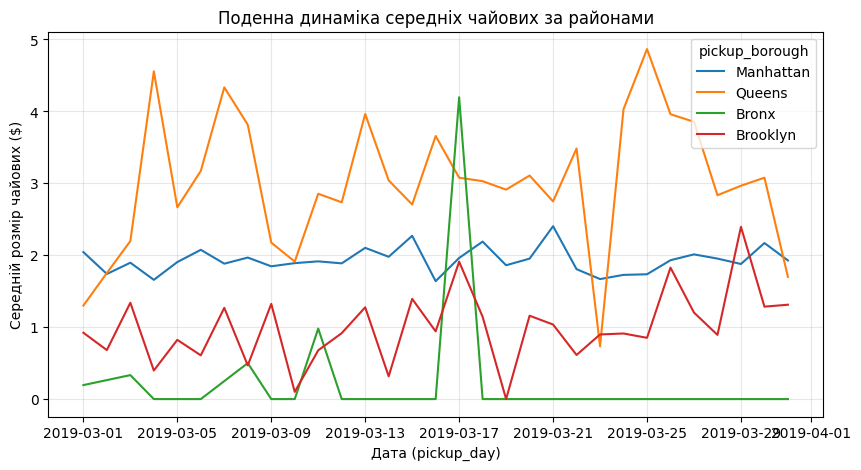

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

df_filtered = df_taxi_clean[df_taxi_clean['pickup_borough'] != 'NA']

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_filtered,
    x='pickup_day',
    y='tip',
    hue='pickup_borough',
    errorbar=None
)

plt.title('Поденна динаміка середніх чайових за районами')
plt.xlabel('Дата (pickup_day)')
plt.ylabel('Середній розмір чайових ($)')
plt.grid(True, alpha=0.3)
plt.show()

**Найнижчий середній розмір чайових: Bronx (Бронкс).** Лінія цього району розташована найнижче на графіку (середні чайові часто близькі до нуля або мінімальні).

**Найвищий середній розмір чайових: Queens (Квінз)**. У цьому районі знаходяться аеропорти (JFK та LaGuardia), через що поїздки мають вищий чек, а чайові нерідко сягають найвищих значень.

**Найстабільніший розмір чайових (найменше коливається): Manhattan (Мангеттен).** Завдяки величезній кількості щоденних стандартних поїздок лінія Мангеттена є найзгладженішою та демонструє найменші амплітуди коливань з дня у день.

Один з можливих результатів (побудовано з seaborn):

![](https://drive.google.com/uc?export=view&id=1yoEqYwNwyQmTTrkk_Mz6D-ruAvE-Sx8q)

14.Побудуйте box-plot розміру чайових по району (всі райони, крім `NA`) старту поїздки. Можна побудувати графік будь-яким методом, який вам до вподоби, чи хочеться потренувати.

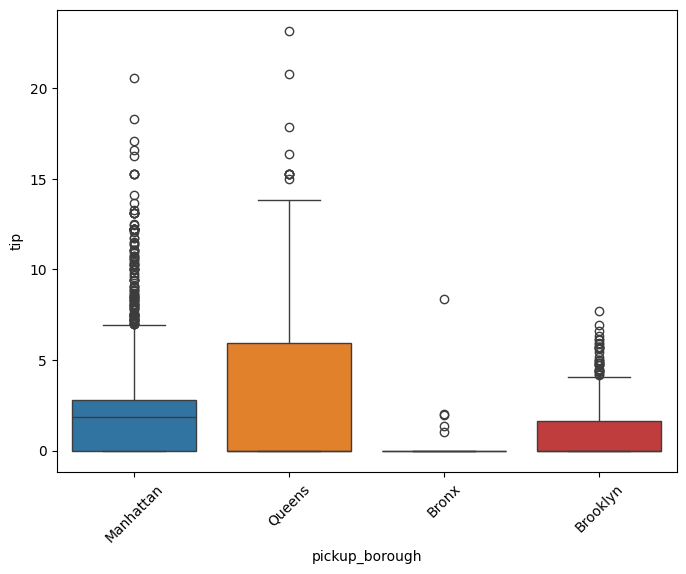

In [48]:
df_filtered = df_taxi_clean[df_taxi_clean['pickup_borough'] != 'NA']

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_filtered,
    x='pickup_borough',
    y='tip',
    hue='pickup_borough',
    legend=False
)

plt.xticks(rotation=45)

plt.show()

Один з можливих результатів (побудовано з seaborn):

![](https://drive.google.com/uc?export=view&id=1o6dFRTSj0gLQ_DMWeb7upqvuPNsL0MQc)

15.Творче завдання. Створіть ТРИ інформативних візуалізації, які б допомогли в аналізі цих даних.   

Що вам було б цікаво дізнатись про ці поїздки? Як це можна було б використати при прийнятті рішень бізнесом?
Наприклад, якщо найбільше поїздок в певний час доби, значить, треба стимулювати водіїв працювати в ці години. Якщо найбільше поїздок з певного району - треба тримати там запас авто, які б могли взяти пасажирів і т.д.
Не обмежуйте свою фантазію.

Візуалізації мають бути не тими, на які ми вже побудували вище. Але можна створювати аналогічні, просто з використанням інших полів даних. І описати, що ви бачите з тих візуалізацій.
Без виконання цього завдання ДЗ не приймаєтья. Якщо є питання щодо виконання - пишіть у чат.

**1. Теплова карта попиту по годинах доби та днях тижня**

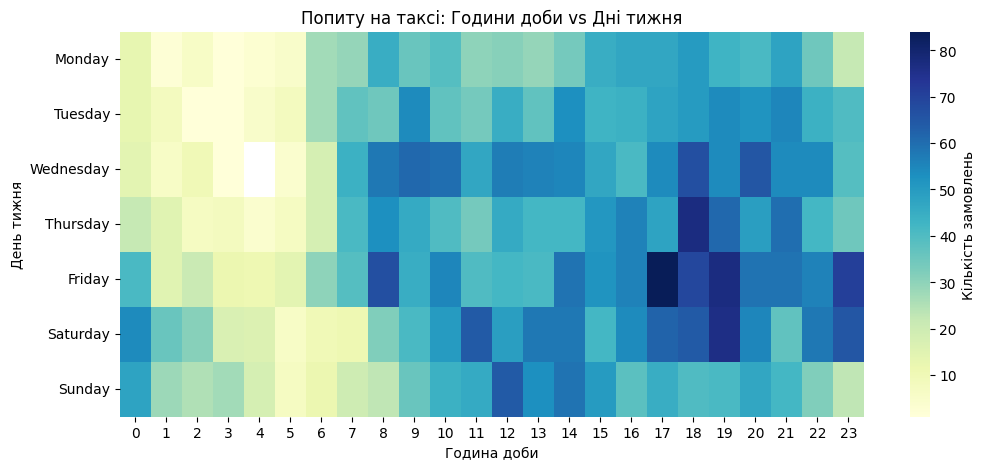

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_taxi_clean['hour'] = df_taxi_clean['pickup'].dt.hour
df_taxi_clean['day_of_week'] = df_taxi_clean['pickup'].dt.day_name()

days_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]

heatmap_demand = df_taxi_clean.pivot_table(
    index='day_of_week', columns='hour', values='total', aggfunc='count'
).reindex(days_order)

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_demand, cmap='YlGnBu', cbar_kws={'label': 'Кількість замовлень'})
plt.title('Попиту на таксі: Години доби vs Дні тижня')
plt.xlabel('Година доби')
plt.ylabel('День тижня')
plt.show()

**Що видно на візуалізації:** яскраво виражені години пік у робочі дні (7:00–9:00 та 17:00–19:00), а також зміщення пікового попиту на нічний час у п'ятницю та суботу (з 21:00 до 02:00).

**Бізнес-рішення:** можливість впровадження динамічного ціноутворення (Surge Pricing) у години найвищого навантаження для підвищення маржинальності та нарахування бонусів водіям за вихід у нічні зміни у вихідні дні.

**2. Матриця переміщень між районами (Pickup vs Dropoff)**

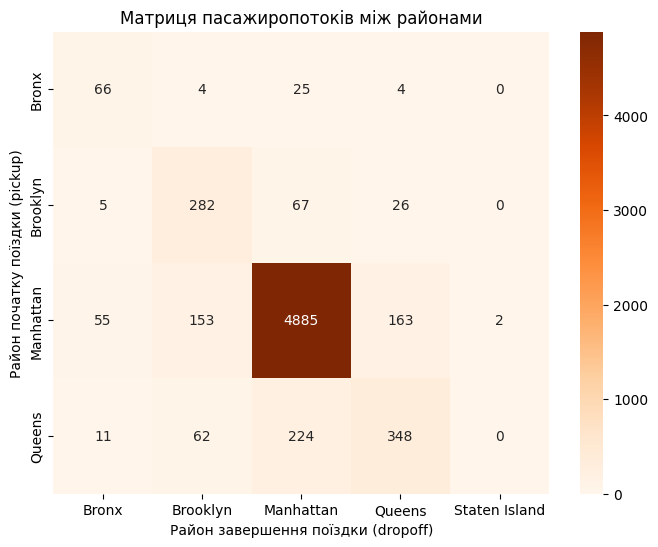

In [50]:
od_matrix = pd.crosstab(
    df_taxi_clean['pickup_borough'], df_taxi_clean['dropoff_borough']
)

od_matrix = od_matrix.drop(index='NA', columns='NA', errors='ignore')

plt.figure(figsize=(8, 6))
sns.heatmap(od_matrix, annot=True, fmt='d', cmap='Oranges')
plt.title('Матриця пасажиропотоків між районами')
plt.xlabel('Район завершення поїздки (dropoff)')
plt.ylabel('Район початку поїздки (pickup)')
plt.show()

**Що видно на візуалізації:** Більшість поїздок починаються та завершуються в межах одного й того ж району (особливо в Мангеттені). Напрямок Мангеттен $\rightarrow$ Квінз займає друге місце за популярністю через транспортне сполучення з аеропортами.
**Бізнес-рішення:** Оптимізація алгоритму розподілу авто для зменшення холостого пробігу. Водіям, які завершили замовлення в Квінзі, додаток має пріоритетно пропонувати зворотні поїздки в Мангеттен.

**3. Порівняння середнього чека залежно від кількості пасажирів та типу оплати**

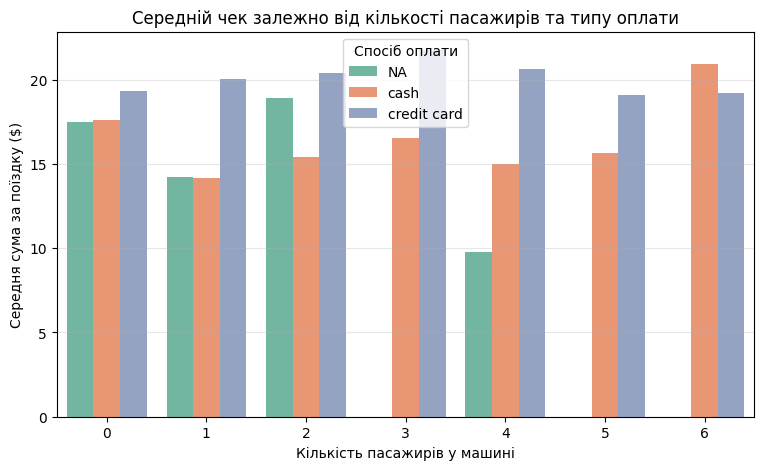

In [51]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_taxi_clean,
    x='passengers',
    y='total',
    hue='payment',
    errorbar=None,
    palette='Set2',
)
plt.title('Середній чек залежно від кількості пасажирів та типу оплати')
plt.xlabel('Кількість пасажирів у машині')
plt.ylabel('Середня сума за поїздку ($)')
plt.legend(title='Спосіб оплати')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Що видно на візуалізації:** поїздки, оплачені безготівковим способом (кредитною карткою), демонструють стабільно вищий середній чек порівняно з оплатою готівкою незалежно від кількості пасажирів. Групові поїздки (5–6 пасажирів) мають вищу середню вартість.

**Бізнес-рішення:** стимулювання безготівкових розрахунків у додатку (програми лояльності, кешбек), оскільки вони генерують вищий чек. Крім того, варто виділяти мікроавтобуси / XL-автомобілі в окремий дорожчий тариф для компаній від 4+ людей.